In [2]:
%pip install pandas matplotlib seaborn numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')

In [4]:
df = pd.read_csv('genz_social_media_usage_1M.csv')
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


# Questions to be Answered

1. Which gender uses social media more?

2. What is the main purpose people use social media?

3. What is the average session time in India?

4. How does daily social media usage affect user mental health?

5. Is the average session minutes affected by the user's age?

6. Is user age and dailysocial media usage affect mental health score?

7. How does daily social media usage, screen time before sleep, and number of platforms used affect a users' mental health?

---

# Question 1: Which gender uses social media more?

In [5]:
gender_table = df.groupby('gender')['daily_usage_hours'].agg(['mean', 'median', 'count'])
gender_table

,mean,median,count
gender,,,
Female,3.515156,3.502646,460801
Male,3.514208,3.503110,460049
Other,3.521148,3.508299,38632


/tmp/ipykernel_2757/3856037615.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='daily_usage_hours', palette='Set2', showfliers=True)


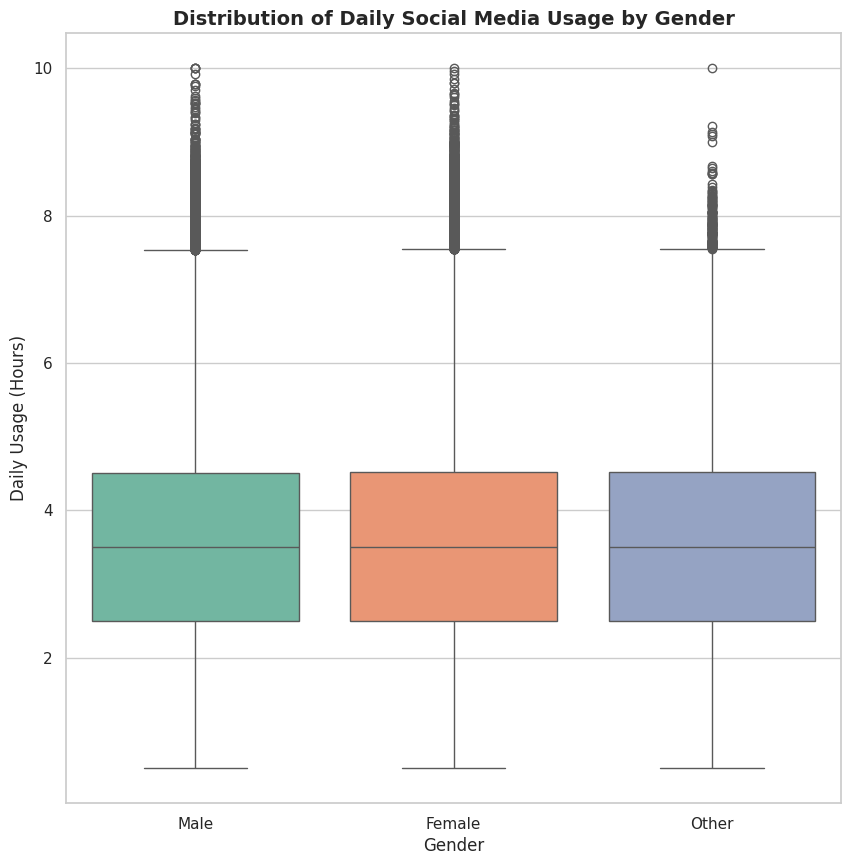

In [6]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='gender', y='daily_usage_hours', palette='Set2', showfliers=True)

plt.title('Distribution of Daily Social Media Usage by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Daily Usage (Hours)', fontsize=12)

plt.show()

As we can see from the able shown and the side-by-side boxplots, there is not a significant difference of daily social media usage between males, females, and other genders. What is even more surprising is that the mean and median are also almost identical, which means that the data is approximately symetrical. All seem to center around 3.5 hours per day. However, the box plots show us the great variability there is for all genders. The IQR is about 7 hours, and there are still many outliers as well.

---

# Question 2: What is the main purpose people use social media?

In [7]:
purpose_counts = df['purpose'].value_counts()

purpose_percentages = df['purpose'].value_counts(normalize=True)

purpose_summary = pd.DataFrame({
    'Total Users': purpose_counts,
    'Percentage (%)': purpose_percentages.round(2)
})

purpose_summary

,Total Users,Percentage (%)
purpose,,
Entertainment,383924,0.40
Socializing,240004,0.25
Education,192235,0.20
News,95682,0.10
Content Creation,47637,0.05


/tmp/ipykernel_2757/2456664818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='purpose', palette='viridis')


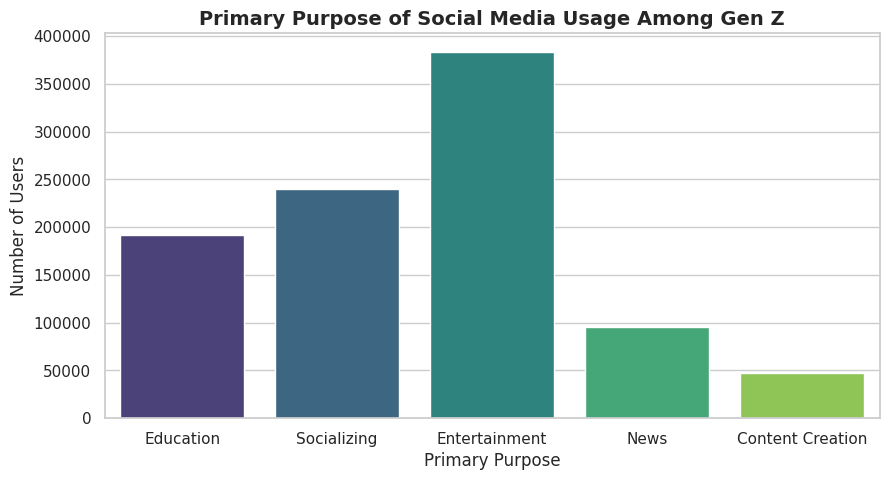

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='purpose', palette='viridis')

plt.title('Primary Purpose of Social Media Usage Among Gen Z', fontsize=14, fontweight='bold')
plt.xlabel('Primary Purpose', fontsize = 12)
plt.ylabel('Number of Users', fontsize=12)

plt.show()

From the table and the bar chart, we can clearly see that Entertainment is the biggest reason people use social media. The table tells us that about 40 percent of users from the dataset use social media for entertainment. We can easily see how many people chose each category and compare them to each other. Like how Socializing is the 2nd biggest reason people use social media, and Content Creation is the smallest.

---

# Question 3: What is the average session time in India?

In [9]:
india_users = df[df['country'] == 'India']

india_avg_session = india_users['avg_session_minutes'].mean()

india_table = pd.DataFrame({
    'Country':'India',
    'Average Session Duration (min)': [india_avg_session]
})

india_table

,Country,Average Session Duration (min)
0,India,25.087886


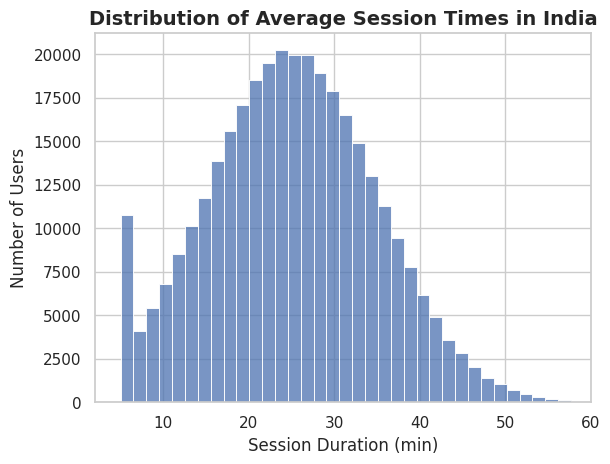

In [10]:
sns.histplot(data=india_users, x='avg_session_minutes', bins=50)

plt.title('Distribution of Average Session Times in India', fontsize=14, fontweight='bold')
plt.xlabel('Session Duration (min)', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xlim(2, 60)

plt.show()

The average session time that India users spend on social media is about 25 minutes. I decided to use a histogram to visualize the data of users in India because it gives us a better idea of how long each users spend on social media in one sitting than just the average. The distribution of average session times in India is almost normally distributed, which is supported by our findings in question 1, and slightly right-sweked. The interesting part of the distribution is that there is a relatively large group of users who use social media for a very short amount of time per day.

---

# Question 4: How does daily social media usage affect user mental health?

In [27]:
sample = df.sample(n=10000, random_state = 12345)

sample[['daily_usage_hours','mental_health_score']].sort_values(by='daily_usage_hours', ascending=False)

,daily_usage_hours,mental_health_score
728681,9.619107,1.528330
248393,8.855135,3.405288
518750,8.769027,1.551111
311766,8.677846,2.740564
336608,8.464144,2.400924
...,...,...
949398,0.500000,9.436254
135053,0.500000,9.959594
151390,0.500000,10.000000
920892,0.500000,9.238710


Text(0, 0.5, 'Mental Health Score (1-10)')

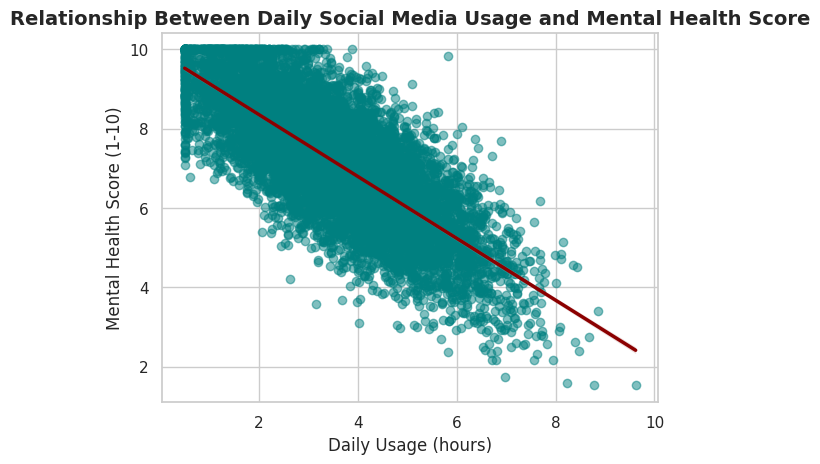

In [22]:
sns.regplot(data=sample, x='daily_usage_hours', y='mental_health_score', scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'darkred', 'linewidth':2.5})

plt.title('Relationship Between Daily Social Media Usage and Mental Health Score', fontsize=14, fontweight='bold')
plt.xlabel('Daily Usage (hours)', fontsize=12)
plt.ylabel('Mental Health Score (1-10)', fontsize=12)

The scatterplot and table uses information on a random sample of 10,000 users. This was so it would better fit in the plot. The scatterplot shows us that there is a strong, negative correlation between social media usage and mental health. As we can see, the users who spend more time on social media have lower mental health scores, meaning worse mental health. I also included the table of real values from the sample so we can compare  mental health scores of those with most usage to those with least usage.

# Question 5: How does daily social media usage affect mental health score?

# Question 6: How does age affect average session minutes?